This file takes in a user-defined class with a certain name. Instantiating the network is simply for testing purposes

In [50]:
from typing import Union
import os
import torch
from torch import nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [51]:
class NetworkAnalyzer:

    def __init__(self, model_architecture: nn.Module, amount_to_produce: int, success_loss: float, convergence_threshold: float = None, max_attempts: float = None):
        """
        Initializes the NetworkAnalyzer class with the required model architecture and configuration.

        Args:
            model_architecture (nn.Module): A PyTorch neural network model class specifying the architecture.
            amount_to_produce (int): Number of good neural networks to generate based on success criteria.
            success_loss (float): Loss amount that qualifies a good network. 
            convergence_threshold (float, optional): Maximum allowable difference in loss between the last two epochs 
                                            of training to determine if the neural network has converged.
            max_attempts (float, optional): Maximum number of attempts to produce a successful network, defaults
                                            to 130% of `amount_to_produce` if not specified.
        """
        self.model_architecture = model_architecture
        self.amount_to_produce = amount_to_produce
        self.success_loss = success_loss if success_loss is not None else self.__default_success_criteria__()
        self.convergence_threshold = convergence_threshold if convergence_threshold is not None else 1000000 #Making it a huge number so it always works
        self.max_attempts = max_attempts if max_attempts is not None else self.__default_max_attempts__()
        
        # Intialize these values to keep track of networks attempts
        self.attempt = 0  
        self.success_count = 0  

        # Array to keep track of loss
        self.train_loss_history = []
        self.test_loss_history = []

        # Ensure directories for saving networks exist
        self.working_dir = "WorkingNetworks"
        self.broken_dir = "BrokenNetworks"
        self.working_networks = {}
        self.broken_networks = {}

        # Set up directories
        if not os.path.exists(self.working_dir):
            os.makedirs(self.working_dir)  # Create directory if it doesn't exist
        if not os.path.exists(self.broken_dir):
            os.makedirs(self.broken_dir)

    def __default_success_criteria__(self):
        """
        Provides a default success criteria if none is specified by the user.
        The default is a loss value of 1.0.

        Returns:
            float: The default success criteria (loss value).
        """
        return 1.0

    def __default_max_attempts__(self):
        """
        Sets the maximum number of attempts to produce successful networks to 130% of the amount requested,
        if not specified by the user.

        Returns:
            int: The calculated maximum number of attempts.
        """
        return int(self.amount_to_produce * 1.3)

    def __show_loss__(self, epoch: int, loss_value: float):
        """
        Prints the loss value for a specific epoch during training.

        Args:
            epoch (int): The current epoch number during training.
            loss_value (float): The loss value for the current epoch.
        """
        print(f"Epoch [{epoch+1}], Loss: {loss_value:.4f}")

    def __test_network__(self, model: nn.Module, test_loader: DataLoader, loss_fn: torch.nn.Module, device):
        """
        Tests the network using the testing dataset, and prints the Test loss

        Args:
            model (nn.Module): The trained PyTorch model to evaluate.
            test_loader (DataLoader): DataLoader for the test dataset, providing batches of test data.
            loss_fn (nn.Module): The loss function used to compute the loss (e.g., nn.CrossEntropyLoss, nn.MSELoss).
            device (torch.device): The device on which to perform the evaluation (e.g., "cuda" or "cpu").
        """
        model.eval()
        test_loss = 0.0

        print("Testing for the epoch")

        with torch.no_grad():  # Disable gradient calculation for testing
            for inputs, targets in test_loader:
                inputs, targets = inputs.to(device), targets.to(device)

                # Forward pass
                outputs = model(inputs)

                # Compute loss
                loss = loss_fn(outputs, targets)
                test_loss += loss.item()


        # Average loss across all test samples
        avg_loss = test_loss / len(test_loader)
        self.test_loss_history.append(avg_loss)
        print(f"Test Loss: {avg_loss:.4f}")

    def __train_network__(self, model: nn.Module, train_loader: DataLoader, test_loader: DataLoader, num_epochs: int, optimizer, loss_fn: torch.nn.Module, device, test: bool):
        """
        Trains a single network model over a specified number of epochs with early stopping.

        Args:
            model (nn.Module): The PyTorch neural network model to train.
            train_loader (DataLoader): The DataLoader for the training dataset.
            num_epochs (int): Number of epochs to train the model.
            optimizer (Optimizer): The optimizer used to update model weights.
            loss_fn (torch.nn.Module): The loss function used to compute the training loss.
            device: The GPU to be used. For now we just assume one.
        """
        
        best_loss = None
        epochs_no_improve = 0
        early_stopping_patience = None
        early_stopping_min_delta = 0.0001

        for epoch in range(num_epochs):
            model.train()
            running_loss = 0.0  # Initialize loss accumulator for the epoch
            for batch in train_loader:
                input, target = batch
                input, target = input.to(device), target.to(device)
                
                optimizer.zero_grad()           
                output = model(input)           
                loss = loss_fn(output, target)  
                loss.backward()                 
                optimizer.step()                

                running_loss += loss.item()

            # Calculate average loss for the epoch
            avg_loss = running_loss / len(train_loader)

            # Show the average loss of the epoch
            self.__show_loss__(epoch, avg_loss)

            # self.__show_loss__(epoch, running_loss)  # Print loss per epoch
            self.train_loss_history.append(avg_loss)

            # Now testing for the epoch
            if test == True:
                self.__test_network__(model, test_loader, loss_fn, device)

    def __check_success__(self, network: torch.nn.Module ):
        
        if self.train_loss_history[-1] <= self.success_loss and (self.train_loss_history[-1] - self.train_loss_history[-2] < self.convergence_threshold):
            self.working_networks[f'network_{self.success_count+1}'] = network.state_dict()

            # self.attempt += 1
            self.success_count += 1
        else:
            self.broken_networks[f'network_{self.success_count+1}_{self.attempt}'] = network.state_dict()
            self.attempt += 1 

    def __get_device__(self):
        # Check for Nvidia GPU
        if torch.cuda.is_available():
            device = torch.device("cuda")
            print(f"Using {device} device!")
        # Check for Mac M GPU
        elif torch.backends.mps.is_available():
            device = torch.device("mps")
            print(f"Using {device} device!")
        else:
            device = torch.device("cpu")
            print("No GPU device available. Using CPU.")
        return device
    
    def __save_networks__(self):
        torch.save(self.working_networks, f'{self.working_dir}/working_networks.pt')
        torch.save(self.broken_networks, f'{self.broken_dir}/broken_networks.pt')

    def __visualize_loss__(self, train, test):
        """"
        Uses all the losses while training to plot a graph.
        can only be used after network generation has been
        """
        if train or test:
            epochs = range(1, max(len(train), len(test)) + 1)

            # Plot training loss if available
            if train:
                plt.plot(epochs, train, label="Training Loss", marker="o")

            # Plot testing loss if available
            if test:
                plt.plot(epochs, test, label="Testing Loss", marker="o")

            # Add labels, title, and legend
            plt.ylabel("Loss")
            plt.xlabel("Epoch")
            plt.title("Training vs Testing Loss")
            plt.legend()
            plt.grid(True)
            plt.show()
        else:
            print("No loss history to plot.")

    def check_loss(self,  train_loader: DataLoader, test_loader: DataLoader, num_epochs: int, loss_fn: torch.nn.Module, learning_rate):
        """
        Trains a single network and prints the training and testing loss

        Args:
            train_loader (DataLoader): DataLoader for the training dataset.
            test_loader (DataLoader): DataLoader for the testing dataset.
            num_epochs (int): The number of epochs to train the network.
            loss_fn (torch.nn.Module): The loss function to calculate the loss during training.
            learning_rate (float): The learning rate for the SGD optimizer.
        """
        device = self.__get_device__()

        network_to_be = self.model_architecture()
        optimizer = torch.optim.SGD(network_to_be.parameters(), lr=learning_rate)  # SGD optimizer

        # Train the network
        network_to_be.to(device)
        self.__train_network__(network_to_be, train_loader, test_loader, num_epochs, optimizer, loss_fn, device, True)

        # Visualize the loss for the single network trained
        self.__visualize_loss__(self.train_loss_history, self.test_loss_history)

        # Resets the loss history for the next networks
        self.train_loss_history = []
        self.test_loss_history = [] 
    
    def generate_networks(self, train_loader: DataLoader, test_loader: DataLoader, num_epochs: int, loss_fn: torch.nn.Module, learning_rate):
        """
        Generates multiple neural networks and trains them until a successful number of networks is produced,
        based on the success criteria and the maximum number of allowed attempts.

        Args:
            train_loader (DataLoader): The DataLoader for the training dataset.
            test_loader (DataLoader): The DataLoader for the testing dataset (unused here but included for completeness).
            num_epochs (int): The number of epochs for which each network should be trained.
            loss_fn (torch.nn.Module): The loss function to use during training.
            learning_rate(float): Learning Rate for the optimizer
        """
        # Get the device to run the network on
        device = self.__get_device__()

        # Start generating networks
        while self.success_count < self.amount_to_produce:
            print(f"Training Network {self.success_count+1}")

            # Stop if maximum attempts are reached
            if self.attempt >= self.max_attempts:
                print("Error: Maximum number of attempts reached without meeting success criteria.")
                break
            
            

            # Instantiate a new network
            network_to_be = self.model_architecture()
            optimizer = torch.optim.SGD(network_to_be.parameters(), lr=learning_rate)
            
            # Train the network
            network_to_be.to(device)
            self.__train_network__(network_to_be, train_loader, test_loader, num_epochs, optimizer, loss_fn, device, False)

            # Check if the network meets the success criteria
            self.__check_success__(network_to_be)
            
        # Display amount of networks created/attempted
        if self.success_count == self.amount_to_produce:
            print(f"Successfully trained {self.success_count} networks.")
        else:
            print(f"{self.success_count} successful networks created out of {self.amount_to_produce}.")
        
        print(f"Attemps:{self.attempt}, successfull networks: {self.success_count}")

        self.__save_networks__()
        
        # Reset these parameters to run the Analyzer again
        self.attempt = 0
        self.success_count = 0
    
    def generate_networks_parallel(self, train_loader: DataLoader, test_loader: DataLoader, num_epochs: int, loss_fn: torch.nn.Module, learning_rate):
        """
        Generates multiple neural networks and trains them, *using GPU and in Parallel*, until a successful number of networks is produced,
        based on the success criteria and the maximum number of allowed attempts.

        Args:
            train_loader (DataLoader): The DataLoader for the training dataset.
            test_loader (DataLoader): The DataLoader for the testing dataset (unused here but included for completeness).
            num_epochs (int): The number of epochs for which each network should be trained.
            loss_fn (torch.nn.Module): The loss function to use during training.
        """
         
        # Check for Nvidia GPU, exit if no GPU
        if not torch.cuda.is_available():
            raise RuntimeError("NVIDIA GPU not available. Cannot train in Parallel")
        else:
            device = torch.device("cuda")
            print(f"Using {device} device!")

        while self.success_count < self.amount_to_produce:
            print(f"Training Network {self.attempt+1}")

            # Stop if maximum attempts are reached
            if self.attempt >= self.max_attempts:
                print("Error: Maximum number of attempts reached without meeting success criteria.")
                break

            # Instantiate a new network
            network_to_be = self.model_architecture()
            optimizer = torch.optim.SGD(network_to_be.parameters(), lr=learning_rate)  # SGD optimizer
            
            # Train the network
            network_to_be = torch.nn.DataParallel(network_to_be)
            self.__train_network_parallel__(network_to_be, train_loader, num_epochs, optimizer, loss_fn, device)

            # Check if the network meets the success criteria
            self.__check_success__(network_to_be)
            self.attempt += 1  # Increment attempt counter

        if self.success_count == self.amount_to_produce:
            print(f"Successfully trained {self.success_count} networks.")
        else:
            print(f"{self.success_count} successful networks created out of {self.amount_to_produce}.")
        
        print(f"Attemps:{self.attempt}, successfull networks: {self.success_count}")
        print("Resetting internal counter of networks...")
        
        # Reset these parameters to run the Analyzer again
        self.attempt = 0
        self.success_count = 0


### Everything past here is testing. Will be deleted before pushing on to main branch

In [52]:
import torch
import torchvision
import torchvision.transforms as transforms
from largerNetArchitecture import LargerNet
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
import pandas as pd
from largerNetArchitecture import LargerNet
from standardRegArchitercture import SimpleNet
from torch.nn import MSELoss

In [53]:
# Read data
csv_data = pd.read_csv('data/simpleReg.csv')

a = csv_data['a'].values.reshape(-1, 1)
b = csv_data['b'].values.reshape(-1, 1)
y = csv_data['y'].values.reshape(-1, 1)

# Convert to Tensors
a_tensor = torch.tensor(a, dtype=torch.float32)
b_tensor = torch.tensor(b, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

# Combine input features
X_tensor = torch.cat((a_tensor, b_tensor), dim=1)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_tensor, y_tensor, test_size=0.2, random_state=42
)

# Create TensorDatasets
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

# Define batch size
batch_size = 64

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)




In [59]:
import sys
loss_fn = MSELoss()
analyzer = NetworkAnalyzer(model_architecture=SimpleNet, amount_to_produce=5, success_loss=0.1, convergence_threshold=1, max_attempts=10)
analyzer.generate_networks(train_loader=train_loader, test_loader=test_loader, num_epochs=200, loss_fn=loss_fn, learning_rate=0.05)

No GPU device available. Using CPU.
Training Network 1


Epoch [1], Loss: 0.3946
Epoch [2], Loss: 0.3610
Epoch [3], Loss: 0.3399
Epoch [4], Loss: 0.3217
Epoch [5], Loss: 0.3052
Epoch [6], Loss: 0.2896
Epoch [7], Loss: 0.2760
Epoch [8], Loss: 0.2631
Epoch [9], Loss: 0.2511
Epoch [10], Loss: 0.2394
Epoch [11], Loss: 0.2300
Epoch [12], Loss: 0.2206
Epoch [13], Loss: 0.2134
Epoch [14], Loss: 0.2068
Epoch [15], Loss: 0.2004
Epoch [16], Loss: 0.1948
Epoch [17], Loss: 0.1903
Epoch [18], Loss: 0.1851
Epoch [19], Loss: 0.1795
Epoch [20], Loss: 0.1763
Epoch [21], Loss: 0.1727
Epoch [22], Loss: 0.1689
Epoch [23], Loss: 0.1651
Epoch [24], Loss: 0.1630
Epoch [25], Loss: 0.1582
Epoch [26], Loss: 0.1544
Epoch [27], Loss: 0.1521
Epoch [28], Loss: 0.1484
Epoch [29], Loss: 0.1455
Epoch [30], Loss: 0.1439
Epoch [31], Loss: 0.1419
Epoch [32], Loss: 0.1390
Epoch [33], Loss: 0.1367
Epoch [34], Loss: 0.1368
Epoch [35], Loss: 0.1331
Epoch [36], Loss: 0.1318
Epoch [37], Loss: 0.1301
Epoch [38], Loss: 0.1293
Epoch [39], Loss: 0.1286
Epoch [40], Loss: 0.1274
Epoch [41

In [ ]:
from dotenv import load_dotenv
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from largerNetArchitecture import LargerNet

In [60]:

working_networks_path = "WorkingNetworks/working_networks.pt"
broken_networks_path = "BrokenNetworks/broken_networks.pt"

#Load in the networks
loaded_state_dict = torch.load(working_networks_path)

#create new instantiations to contain the saved networks
num_networks = len(loaded_state_dict)
networks = []
for n in range(num_networks):
    networks.append(SimpleNet())

for i, network in enumerate(networks):
    state_dict_key = f'network_{i+1}'
    network.load_state_dict(loaded_state_dict[state_dict_key])




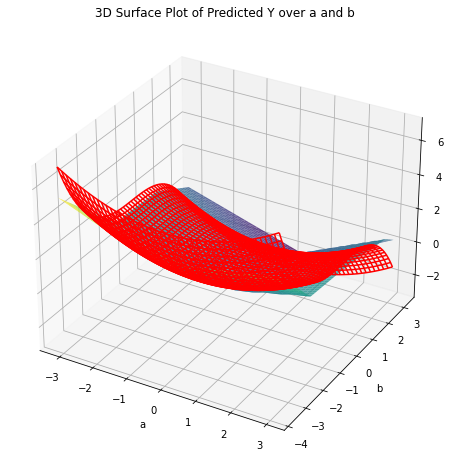

In [62]:
from mpl_toolkits.mplot3d import Axes3D

def target_function(a, b):
    return (1/5) * a**2 - (1/10) * b**3

network = networks[3]

# Create a grid of values
a_range = np.linspace(a_tensor.min(), a_tensor.max(), 50)
b_range = np.linspace(b_tensor.min(), b_tensor.max(), 50)
A, B = np.meshgrid(a_range, b_range)
grid = np.c_[A.ravel(), B.ravel()]
grid_tensor = torch.tensor(grid, dtype=torch.float32)

# Get predictions
network.eval()
with torch.no_grad():
    y_pred_grid = network(grid_tensor).numpy()

# Reshape predictions to match grid
Y_pred_grid = y_pred_grid.reshape(A.shape)

# Plot the surface
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(A, B, Y_pred_grid, cmap='viridis', alpha=0.8)

# Optionally plot the actual target function for comparison
# Compute actual Y values using the target function
Y_actual_grid = target_function(A, B)

# Plot the actual surface
ax.plot_wireframe(A, B, Y_actual_grid, color='r', label='Actual Function')

ax.set_xlabel('a')
ax.set_ylabel('b')
ax.set_zlabel('Predicted Y')
plt.title('3D Surface Plot of Predicted Y over a and b')
plt.show()
